In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime

In [3]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [4]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
DIR_MODEL = yml["SETTING"]["DIR_MODEL"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

In [5]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner, MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_LSTM_mult import model_LSTM_mult
from src.model_ASMBL import model_ASMBL_demand_supply_intervention
from src.util import Logger, Util

/Users/ishizuka/opt/anaconda3/envs/mufgcup2024/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def load_feature(file_name):
    file_name = file_name + ".pkl"
    return pd.read_pickle(os.path.join(DIR_FEATURE, file_name))

# LGBM_台数

In [151]:
# datasetの作成
df_main_lgb_bikes = load_feature("df_key")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_datetime_atr"), on=["datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_weather_feat"), on=["datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_rolling"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_lr"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
# df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_demand_rolling"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_supply_rolling"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_intervention_rolling"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_demand_lr"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_supply_lr"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_intervention_lr"), on=["station_id", "datetime"], how="left")
df_main_lgb_bikes = pd.merge(df_main_lgb_bikes, load_feature("df_bikes_available_rate_lag"), on=["station_id", "datetime"], how="left")

In [153]:
df_main_lgb_bikes.tail()

,station_id,datetime,predict,bikes_available,bikes_available_lag0,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,...,dock_count_rate_lag15,dock_count_rate_lag16,dock_count_rate_lag17,dock_count_rate_lag18,dock_count_rate_lag19,dock_count_rate_lag20,dock_count_rate_lag21,dock_count_rate_lag22,dock_count_rate_lag23,dock_count_rate_lag24
1226395,69,2015-08-31 19:00:00,0,8.0,8.0,7.0,7.0,7.0,7.0,7.0,...,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.600000,0.600000,0.600000
1226396,69,2015-08-31 20:00:00,0,8.0,8.0,8.0,7.0,7.0,7.0,7.0,...,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.600000,0.600000
1226397,69,2015-08-31 21:00:00,0,8.0,8.0,8.0,8.0,7.0,7.0,7.0,...,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.600000
1226398,69,2015-08-31 22:00:00,0,8.0,8.0,8.0,8.0,8.0,7.0,7.0,...,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667
1226399,69,2015-08-31 23:00:00,0,8.0,8.0,8.0,8.0,8.0,8.0,7.0,...,0.600000,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667


In [47]:
# df_main_lgb_bikes.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_bikes.pkl"))
# df_main_lgb_bikes = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lgb_new.pkl"))

In [48]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [62]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel_bikes")
# run_name = 'lgbm_multimodel_202410132324'
run_name

'lgbm_multimodel_bikes_202410202300'

In [63]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left", suffixes=("", "_"))
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 5000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    "lambda_l1": 0.1,
    "lambda_l2": 0.1,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [64]:
memo = "LightGBM23期マルチモデル lambda1=0.1, lambda2=0.1"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb,
    df_main_lgb_bikes,
    run_setting,
    cv_setting,
    logger,
    memo)

In [65]:
ml_runner.run_train_cv()

[2024-10-20 23:00:06] - lgbm_multimodel_bikes_202410202300 - start training cv
[2024-10-20 23:00:06] - lgbm_multimodel_bikes_202410202300 fold 2014-09-01 - start training


term: 1, tr_x: (22476, 143), tr_y: (22476, 1), va_x: (2170, 143), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.290094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3216
[LightGBM] [Info] Number of data points in the train set: 22476, number of used features: 142
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.27635	eval's l1: 1.45292
[200]	train's l1: 0.695966	eval's l1: 0.834811
[300]	train's l1: 0.458687	eval's l1: 0.556269
[400]	train's l1: 0.317968	eval's l1: 0.378012
[500]	train's l1: 0.238855	eval's l1: 0.282709
[600]	train's l1: 0.197072	eval's l1: 0.234349
[700]	train's l1: 0.177437	eval's l1: 0.211468
[800]	train's l1: 0.171723	eval's l1: 0.203675
[900]	train's l1: 0.169349	eval's l1: 0.200763
[1000]	train's l1: 0.16884	e

[2024-10-20 23:04:17] - lgbm_multimodel_bikes_202410202300 fold 2014-09-01 - end training
[2024-10-20 23:04:17] - lgbm_multimodel_bikes_202410202300 fold 2014-10-01 - start training


term: 1, tr_x: (24646, 143), tr_y: (24646, 1), va_x: (420, 143), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3272
[LightGBM] [Info] Number of data points in the train set: 24646, number of used features: 142
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.29539	eval's l1: 1.37821
[200]	train's l1: 0.725633	eval's l1: 0.804838
[300]	train's l1: 0.505854	eval's l1: 0.542086
[400]	train's l1: 0.364035	eval's l1: 0.377671
[500]	train's l1: 0.257427	eval's l1: 0.269205
[600]	train's l1: 0.209032	eval's l1: 0.214944
[700]	train's l1: 0.183406	eval's l1: 0.186246
[800]	train's l1: 0.171332	eval's l1: 0.173494
[900]	train's l1: 0.168625	eval's l1: 0.169515
[1000]	train's l1: 0.167648	ev

[2024-10-20 23:07:31] - lgbm_multimodel_bikes_202410202300 fold 2014-10-01 - end training
[2024-10-20 23:07:31] - lgbm_multimodel_bikes_202410202300 fold 2014-11-01 - start training


...

[2024-10-20 23:42:54] - lgbm_multimodel_bikes_202410202300 fold 2015-06-01 - end training
[2024-10-20 23:42:54] - lgbm_multimodel_bikes_202410202300 fold 2015-07-01 - start training


term: 1, tr_x: (37456, 143), tr_y: (37456, 1), va_x: (280, 143), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3391
[LightGBM] [Info] Number of data points in the train set: 37456, number of used features: 142
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.36995	eval's l1: 1.46488
[200]	train's l1: 0.647887	eval's l1: 0.689028
[300]	train's l1: 0.413699	eval's l1: 0.450296
[400]	train's l1: 0.299702	eval's l1: 0.290449
[500]	train's l1: 0.238567	eval's l1: 0.214166
[600]	train's l1: 0.203978	eval's l1: 0.172984
[700]	train's l1: 0.188689	eval's l1: 0.15544
[800]	train's l1: 0.184858	eval's l1: 0.151077
[900]	train's l1: 0.181678	eval's l1: 0.147381
[1000]	train's l1: 0.17992	eval

[2024-10-20 23:47:30] - lgbm_multimodel_bikes_202410202300 fold 2015-07-01 - end training
[2024-10-20 23:47:30] - lgbm_multimodel_bikes_202410202300 fold 2015-08-01 - start training


term: 1, tr_x: (38856, 143), tr_y: (38856, 1), va_x: (350, 143), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3398
[LightGBM] [Info] Number of data points in the train set: 38856, number of used features: 142
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.37641	eval's l1: 1.29753
[200]	train's l1: 0.666152	eval's l1: 0.602408
[300]	train's l1: 0.451176	eval's l1: 0.399339
[400]	train's l1: 0.308927	eval's l1: 0.255251
[500]	train's l1: 0.241494	eval's l1: 0.198316
[600]	train's l1: 0.210266	eval's l1: 0.174037
[700]	train's l1: 0.195511	eval's l1: 0.166554
[800]	train's l1: 0.190931	eval's l1: 0.166841
Early stopping, best iteration is:
[716]	train's l1: 0.194607	eval's l1: 0.16

[2024-10-20 23:51:37] - lgbm_multimodel_bikes_202410202300 fold 2015-08-01 - end training
[2024-10-20 23:51:37] - lgbm_multimodel_bikes_202410202300 - end training cv


In [66]:
ml_runner.run_metric_cv()

[2024-10-20 23:51:38] - lgbm_multimodel_bikes_202410202300 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

(10080, 147)


  8%|▊         | 1/12 [00:26<04:52, 26.58s/it]

(10080, 147)


 17%|█▋        | 2/12 [00:50<04:12, 25.29s/it]

...

 83%|████████▎ | 10/12 [09:04<02:49, 84.95s/it]

(8400, 147)


 92%|█████████▏| 11/12 [17:49<03:39, 219.72s/it]

(8400, 147)


100%|██████████| 12/12 [18:14<00:00, 91.17s/it] 
memo: LightGBM23期マルチモデル lambda1=0.1, lambda2=0.1
run_name:lgbm_multimodel_bikes_202410202300	score_mean:1.521311860583058	score0:1.5643253745387227	score1:1.7506538024005849	score2:1.4884944967225724	score3:1.514231123936138	score4:1.5105482799957282	score5:1.3515088700624394	score6:1.527781587658544	score7:1.4754333594548497	score8:1.4589962025616916	score9:1.53746922553879	score10:1.594182365605468	score11:1.4821176385211665
mean: 1.521311860583058, std: 0.0902132697994391
[2024-10-21 00:09:52] - mean: 1.521311860583058, std: 0.0902132697994391
[2024-10-21 00:09:52] - output predict : ../models/lgbm_multimodel_bikes_202410202300/va_pred.pkl
[2024-10-21 00:09:52] - lgbm_multimodel_bikes_202410202300 - end metric cv


In [67]:
ml_runner.run_predict_cv()

[2024-10-21 00:09:52] - lgbm_multimodel_bikes_202410202300 - start prediction cv
100%|██████████| 12/12 [05:00<00:00, 25.03s/it]
[2024-10-21 00:14:53] - output predict : ../models/lgbm_multimodel_bikes_202410202300/te_pred.pkl
[2024-10-21 00:14:53] - lgbm_multimodel_bikes_202410202300 - end prediction cv


In [68]:
ml_runner.plot_feature_importance_cv()

[2024-10-21 00:14:53] - lgbm_multimodel_bikes_202410202300 - start plot feature importance cv
[2024-10-21 00:15:47] - lgbm_multimodel_bikes_202410202300 - end plot feature importance cv


In [57]:
# 予測値確認

In [58]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル demand_lag, supply_lag, intervention_lag追加


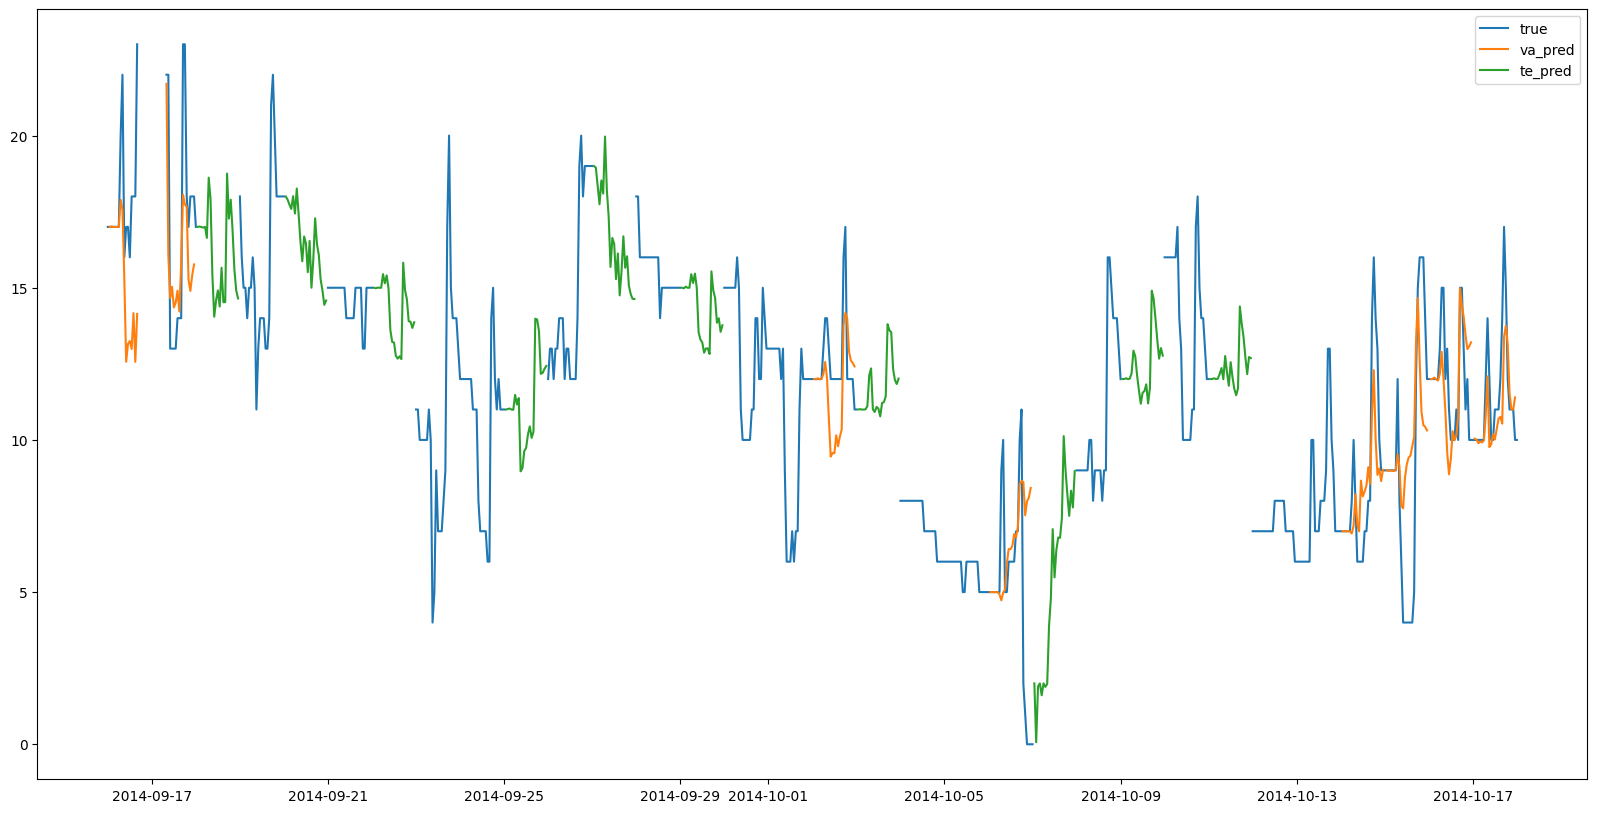

In [59]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル lagを48に変更


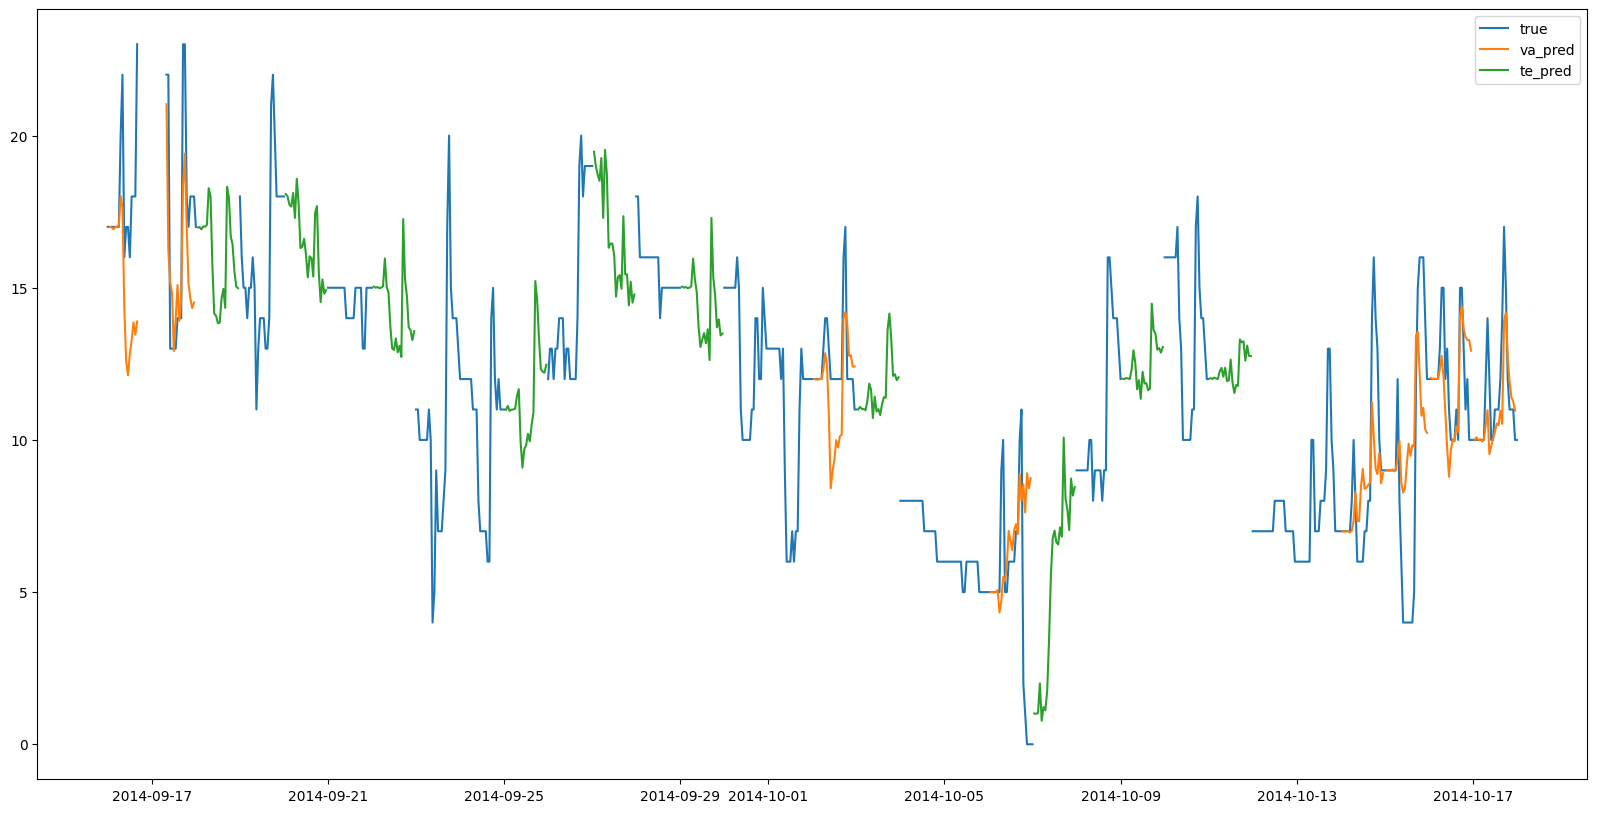

In [20]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル weather特徴量追加


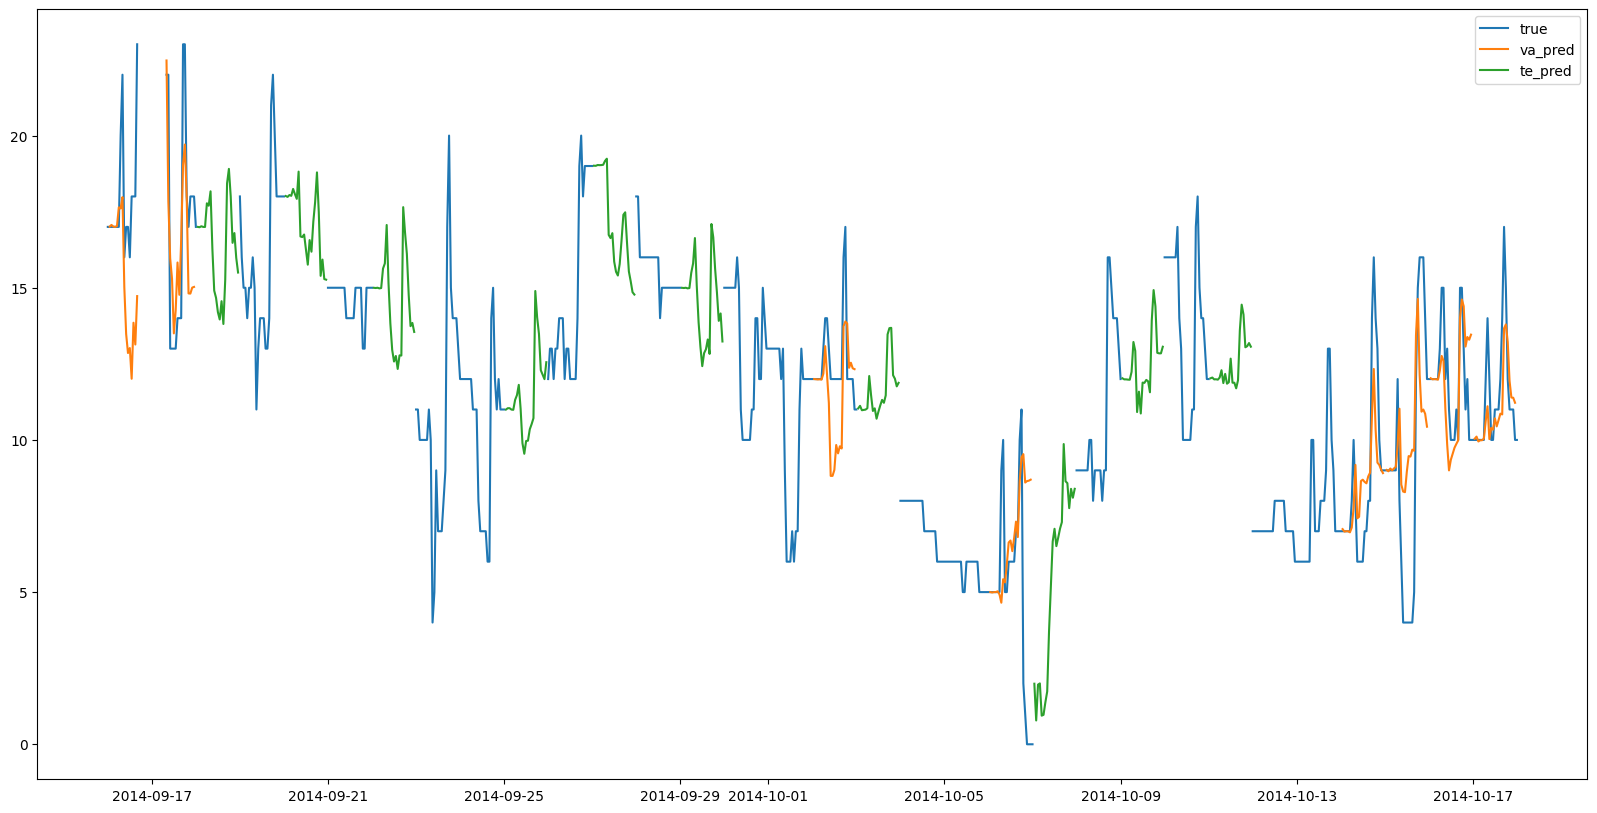

In [22]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM_台数

In [ ]:
df_main_lstm_new = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lstm_new.pkl"))

In [ ]:
df_main_lstm_new

,station_id,datetime,predict,bikes_available,weekday
0,0,2013-09-01 00:00:00,0,11.0,6
1,1,2013-09-01 00:00:00,0,8.0,6
2,2,2013-09-01 00:00:00,0,5.0,6
3,3,2013-09-01 00:00:00,0,9.0,6
4,4,2013-09-01 00:00:00,0,8.0,6
...,...,...,...,...,...
1226395,65,2015-08-31 23:00:00,0,13.0,0
1226396,66,2015-08-31 23:00:00,0,7.0,0
1226397,67,2015-08-31 23:00:00,0,6.0,0
1226398,68,2015-08-31 23:00:00,0,5.0,0


In [ ]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from datetime import datetime
from src.util import Logger

In [ ]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [ ]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [ ]:
logger = Logger(path=DIR_LOG)

In [ ]:
run_name = get_run_name(model_type="lstm_mult")
# run_name = 'lstm_mult_202410132245'
run_name

'lstm_mult_202410181108'

In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [ ]:
model_params = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "seq_length": 24,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 10,
    "learning_rate": 0.001,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [ ]:
memo = "LSTMのマルチステップ予測 後処理追加"
timeseries_runner = TimeseriesModelRunner(run_name,
                                          model_LSTM_mult,
                                          model_params,
                                          df_main_lstm_new,
                                          run_setting,
                                          cv_setting,
                                          logger,
                                          memo)

In [ ]:
timeseries_runner.run_train_cv()

[2024-10-18 11:08:36] - lstm_mult_202410181108 - start training cv
[2024-10-18 11:08:36] - lstm_mult_202410181108 fold 2014-09-01 - start training


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
24576 24576
(24576, 24, 2) (24576, 23)
torch.Size([24576, 24, 2]) torch.Size([24576, 23])
24576
384
2
model
criterion


In [ ]:
timeseries_runner.run_metric_cv()

[2024-10-14 14:48:08] - lstm_mult_202410132245 - start metric cv
100%|██████████| 12/12 [00:23<00:00,  1.95s/it]
memo: LSTMのマルチステップ予測 後処理追加
run_name:lstm_mult_202410132245	score_mean:1.6819826614430216	score0:1.7368062295534643	score1:1.8970805470764205	score2:1.6028723657051864	score3:1.658505381214091	score4:1.6624859627015631	score5:1.5040819079485985	score6:1.702690100422395	score7:1.622700958258432	score8:1.617622394960939	score9:1.7418933251045943	score10:1.793829023956512	score11:1.6432237404140626
mean: 1.6819826614430216, std: 0.09738140548426347
[2024-10-14 14:48:31] - mean: 1.6819826614430216, std: 0.09738140548426347
[2024-10-14 14:48:31] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/va_pred.pkl
[2024-10-14 14:48:31] - lstm_mult_202410132245 - end metric cv


In [ ]:
timeseries_runner.run_predict_cv()

[2024-10-14 14:50:09] - lstm_mult_202410132245 - start prediction cv
100%|██████████| 12/12 [00:38<00:00,  3.17s/it]
[2024-10-14 14:50:48] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/te_pred.pkl
[2024-10-14 14:50:48] - lstm_mult_202410132245 - end prediction cv


In [ ]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTMのマルチステップ予測 学習率0.001 epoch5


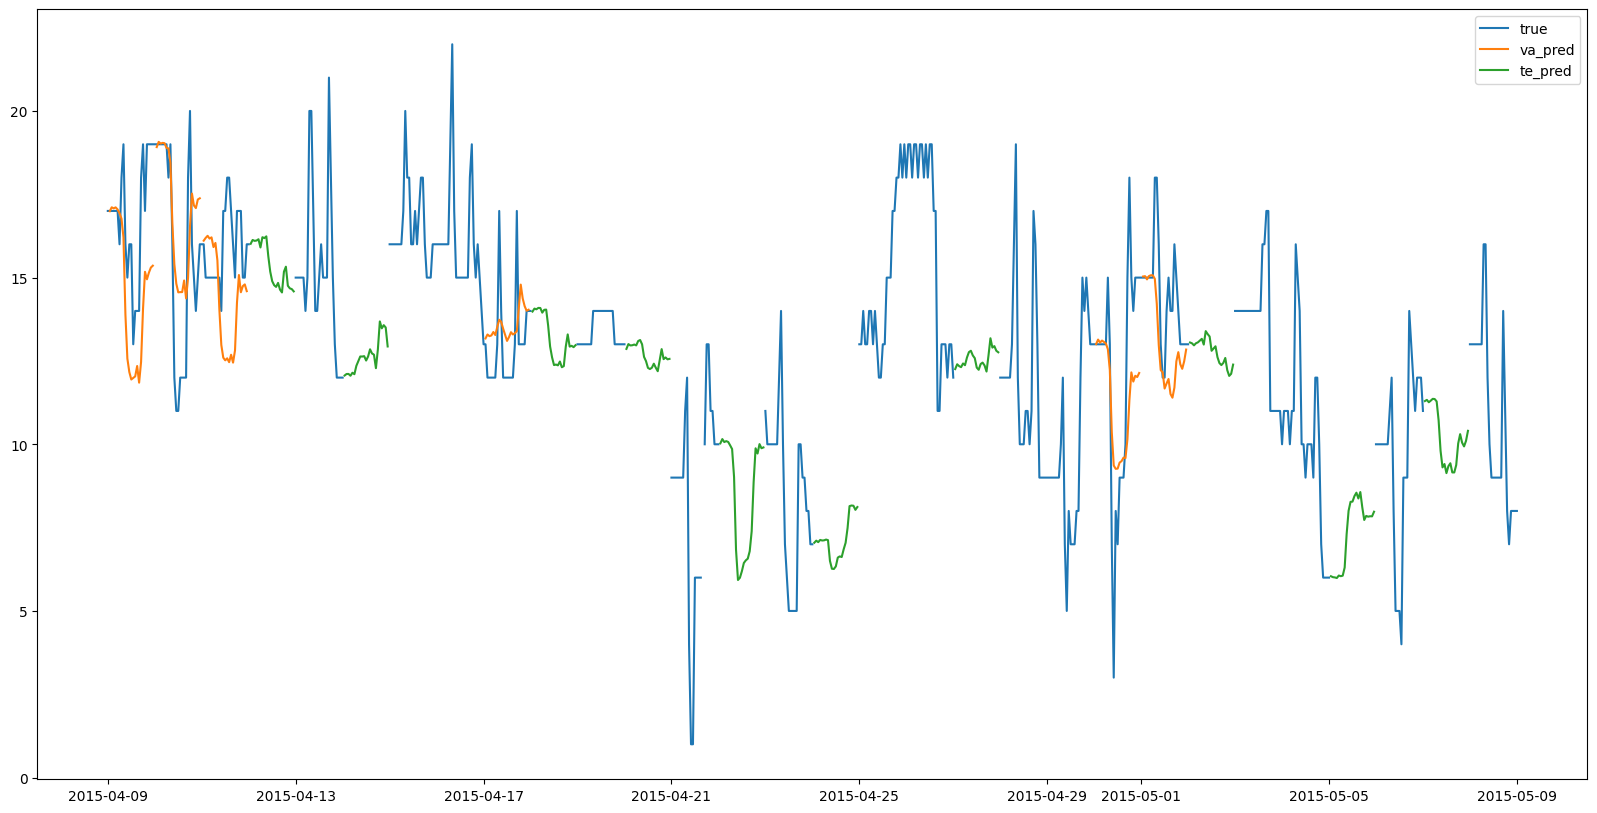

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTMのマルチステップ予測 学習率0.001 epoch5


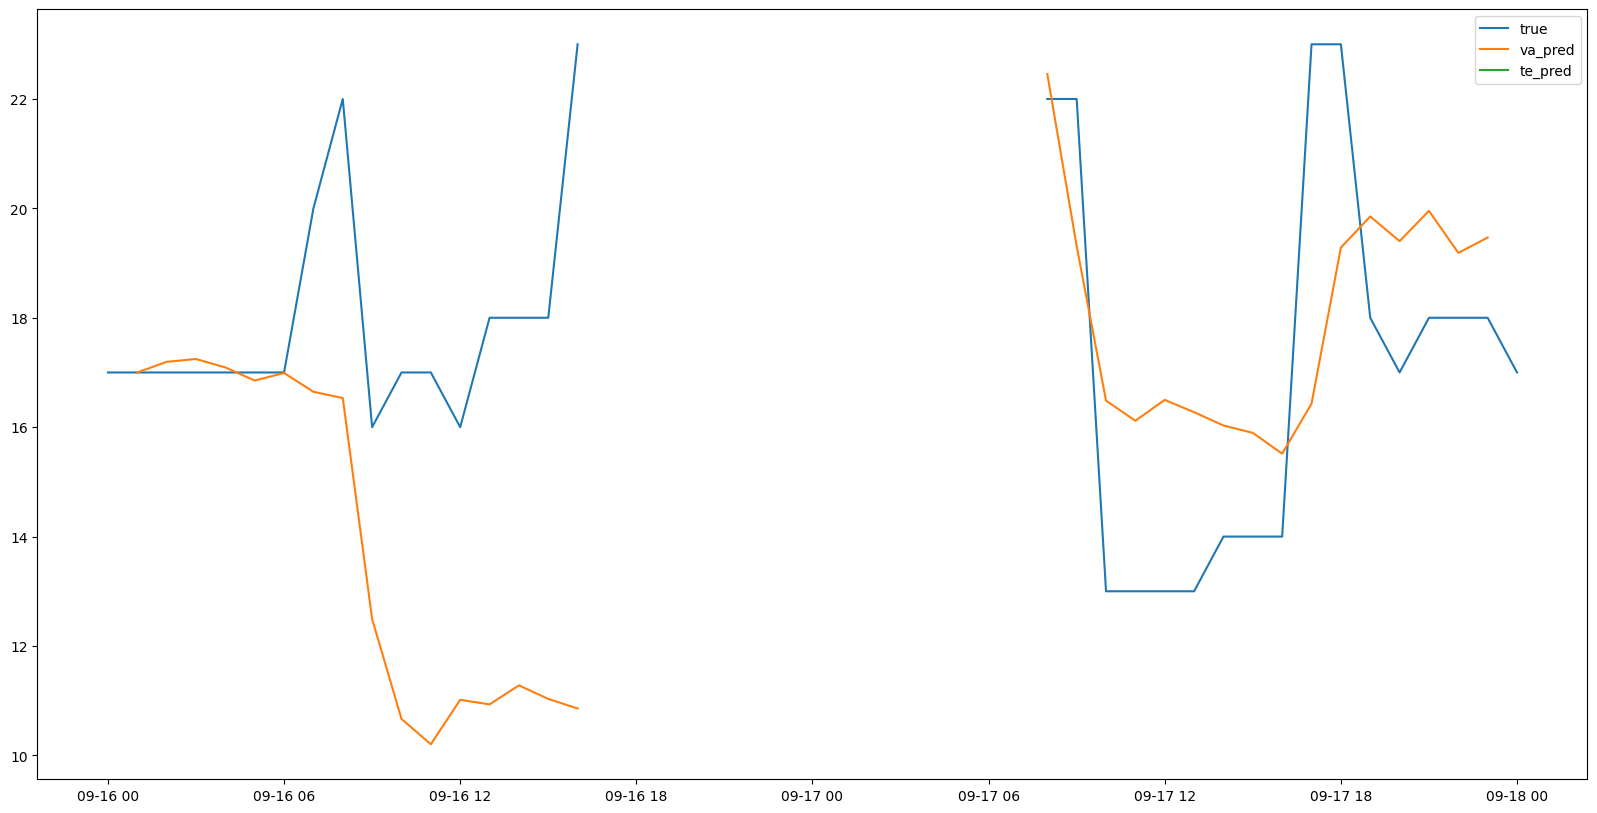

In [ ]:
# 元の目的関数が欠損している部分（）
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
# 学習データ数の推移
for month in range(8, 13):
    i_fold = datetime(2014, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

for month in range(1, 9):
    i_fold = datetime(2015, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

2014-08-01 00:00:00 (22406, 24, 2)
2014-09-01 00:00:00 (24576, 24, 2)
2014-10-01 00:00:00 (25276, 24, 2)
2014-11-01 00:00:00 (26046, 24, 2)
2014-12-01 00:00:00 (26746, 24, 2)
2015-01-01 00:00:00 (27516, 24, 2)
2015-02-01 00:00:00 (28286, 24, 2)
2015-03-01 00:00:00 (28846, 24, 2)
2015-04-01 00:00:00 (29616, 24, 2)
2015-05-01 00:00:00 (30316, 24, 2)
2015-06-01 00:00:00 (31086, 24, 2)
2015-07-01 00:00:00 (31786, 24, 2)
2015-08-01 00:00:00 (32556, 24, 2)


# LGBM_需要

In [69]:

df_main_lgb_demand = load_feature("df_key")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand_cumsum"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_datetime_atr"), on=["datetime"], how="left")


In [71]:
df_main_lgb_demand.head()

,station_id,datetime,predict,demand_cumsum,demand_lag0,demand_lag1,demand_lag2,demand_lag3,demand_lag4,demand_lag5,...,city_city3,city_city4,city_city5,datetime_feat,year,month,day,hour,weekday,holiday
0,0,2013-09-01 00:00:00,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,20130901,2013,9,1,0,6,1
1,0,2013-09-01 01:00:00,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,0,0,0,20130901,2013,9,1,1,6,1
2,0,2013-09-01 02:00:00,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,...,0,0,0,20130901,2013,9,1,2,6,1
3,0,2013-09-01 03:00:00,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,0,0,0,20130901,2013,9,1,3,6,1
4,0,2013-09-01 04:00:00,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,0,0,0,20130901,2013,9,1,4,6,1


In [72]:
df_main_lgb_demand.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_demand.pkl"))

In [73]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [74]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_demand")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_demand_202410210031'

In [75]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(upper=0)

    return df_pred

In [76]:
model_params_lgb_demand = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_demand = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_demand = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [77]:
memo = "LightGBM23期マルチモデル demand_cumsum"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_demand,
    df_main_lgb_demand,
    run_setting_lgb_demand,
    cv_setting_lgb_demand,
    logger,
    memo)

In [78]:
ml_runner.run_train_cv()

[2024-10-21 00:32:47] - lgbm_multiml_demand_202410210031 - start training cv
[2024-10-21 00:32:47] - lgbm_multiml_demand_202410210031 fold 2014-09-01 - start training


term: 1, tr_x: (23380, 94), tr_y: (23380, 1), va_x: (2170, 94), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1853
[LightGBM] [Info] Number of data points in the train set: 23380, number of used features: 93
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0873851	eval's l1: 0.103038
[200]	train's l1: 0.0716833	eval's l1: 0.0847514
[300]	train's l1: 0.065936	eval's l1: 0.0780581
[400]	train's l1: 0.0638322	eval's l1: 0.0756081
[500]	train's l1: 0.0630622	eval's l1: 0.0747113
[600]	train's l1: 0.0627804	eval's l1: 0.0743831
[700]	train's l1: 0.0626772	eval's l1: 0.0742629
[800]	train's l1: 0.0626394	eval's l1: 0.0742189
[900]	train's l1: 0.0626256	eval's l1: 0.0742028
[1000]	train's l1: 0.0626205	eval's l1: 0.074197
[1100]	train's l1

[2024-10-21 00:35:53] - lgbm_multiml_demand_202410210031 fold 2014-09-01 - end training
[2024-10-21 00:35:53] - lgbm_multiml_demand_202410210031 fold 2014-10-01 - start training


term: 1, tr_x: (25550, 94), tr_y: (25550, 1), va_x: (420, 94), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1896
[LightGBM] [Info] Number of data points in the train set: 25550, number of used features: 93
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0887145	eval's l1: 0.102974
[200]	train's l1: 0.0727932	eval's l1: 0.0875034
[300]	train's l1: 0.0669655	eval's l1: 0.0818408
[400]	train's l1: 0.0648324	eval's l1: 0.0797681
[500]	train's l1: 0.0640516	eval's l1: 0.0790095
[600]	train's l1: 0.0637658	eval's l1: 0.0787318
[700]	train's l1: 0.0636612	eval's l1: 0.0786301
[800]	train's l1: 0.0636229	eval's l1: 0.0785929
[900]	train's l1: 0.0636089	eval's l1: 0.0785793
[1000]	train's l1: 0.0636037	eval's l1: 0.0785743
[1100]	train's l1

[2024-10-21 00:39:14] - lgbm_multiml_demand_202410210031 fold 2014-10-01 - end training
[2024-10-21 00:39:14] - lgbm_multiml_demand_202410210031 fold 2014-11-01 - start training


...

[2024-10-21 01:04:15] - lgbm_multiml_demand_202410210031 fold 2015-06-01 - end training
[2024-10-21 01:04:15] - lgbm_multiml_demand_202410210031 fold 2015-07-01 - start training


term: 1, tr_x: (44660, 94), tr_y: (44660, 1), va_x: (280, 94), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012895 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2063
[LightGBM] [Info] Number of data points in the train set: 44660, number of used features: 93
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0862964	eval's l1: 0.0348515
[200]	train's l1: 0.0700278	eval's l1: 0.0240776
[300]	train's l1: 0.0640729	eval's l1: 0.020134
[400]	train's l1: 0.0618933	eval's l1: 0.0186906
[500]	train's l1: 0.0610954	eval's l1: 0.0181622
[600]	train's l1: 0.0608034	eval's l1: 0.0179688
[700]	train's l1: 0.0606965	eval's l1: 0.017898
[800]	train's l1: 0.0606574	eval's l1: 0.0178721
[900]	train's l1: 0.0606431	eval's l1: 0.0178626
[1000]	train's l1: 0.0606378	eval's l1: 0.0178591
[1100]	train's l1:

[2024-10-21 01:07:30] - lgbm_multiml_demand_202410210031 fold 2015-07-01 - end training
[2024-10-21 01:07:30] - lgbm_multiml_demand_202410210031 fold 2015-08-01 - start training


term: 1, tr_x: (46760, 94), tr_y: (46760, 1), va_x: (350, 94), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014668 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2070
[LightGBM] [Info] Number of data points in the train set: 46760, number of used features: 93
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0855961	eval's l1: 0.0794136
[200]	train's l1: 0.0694676	eval's l1: 0.0635015
[300]	train's l1: 0.063564	eval's l1: 0.0576771
[400]	train's l1: 0.0614031	eval's l1: 0.0555452
[500]	train's l1: 0.0606121	eval's l1: 0.0547648
[600]	train's l1: 0.0603226	eval's l1: 0.0544792
[700]	train's l1: 0.0602167	eval's l1: 0.0543746
[800]	train's l1: 0.0601779	eval's l1: 0.0543364
[900]	train's l1: 0.0601637	eval's l1: 0.0543224
[1000]	train's l1: 0.0601585	eval's l1: 0.0543172
[1100]	train's l1

[2024-10-21 01:12:11] - lgbm_multiml_demand_202410210031 fold 2015-08-01 - end training
[2024-10-21 01:12:11] - lgbm_multiml_demand_202410210031 - end training cv


In [79]:
ml_runner.run_metric_cv()

[2024-10-21 01:12:12] - lgbm_multiml_demand_202410210031 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

(10080, 98)


  8%|▊         | 1/12 [00:21<03:57, 21.61s/it]

(10080, 98)


 17%|█▋        | 2/12 [00:42<03:31, 21.17s/it]

...

 83%|████████▎ | 10/12 [03:18<00:38, 19.40s/it]

(8400, 98)


 92%|█████████▏| 11/12 [03:37<00:19, 19.21s/it]

(8400, 98)


100%|██████████| 12/12 [03:56<00:00, 19.73s/it]
memo: LightGBM23期マルチモデル demand_cumsum
run_name:lgbm_multiml_demand_202410210031	score_mean:1.9656235186597586	score0:1.9774222104114436	score1:1.9631329323442057	score2:2.6709015099212943	score3:1.3181792689260698	score4:2.524871637607676	score5:2.3069873505410006	score6:1.862819499860586	score7:1.5797263257335608	score8:1.5574192576319048	score9:2.1544267097536336	score10:1.9225295651809788	score11:1.7490659560047475
mean: 1.9656235186597586, std: 0.38259543233566995
[2024-10-21 01:16:08] - mean: 1.9656235186597586, std: 0.38259543233566995
[2024-10-21 01:16:08] - output predict : ../models/lgbm_multiml_demand_202410210031/va_pred.pkl
[2024-10-21 01:16:08] - lgbm_multiml_demand_202410210031 - end metric cv


In [80]:
ml_runner.run_predict_cv()

[2024-10-21 01:16:08] - lgbm_multiml_demand_202410210031 - start prediction cv
100%|██████████| 12/12 [03:54<00:00, 19.56s/it]
[2024-10-21 01:20:03] - output predict : ../models/lgbm_multiml_demand_202410210031/te_pred.pkl
[2024-10-21 01:20:03] - lgbm_multiml_demand_202410210031 - end prediction cv


In [81]:
ml_runner.plot_feature_importance_cv()

[2024-10-21 01:20:03] - lgbm_multiml_demand_202410210031 - start plot feature importance cv
[2024-10-21 01:20:48] - lgbm_multiml_demand_202410210031 - end plot feature importance cv


In [82]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_lgb_demand[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル demand_cumsum


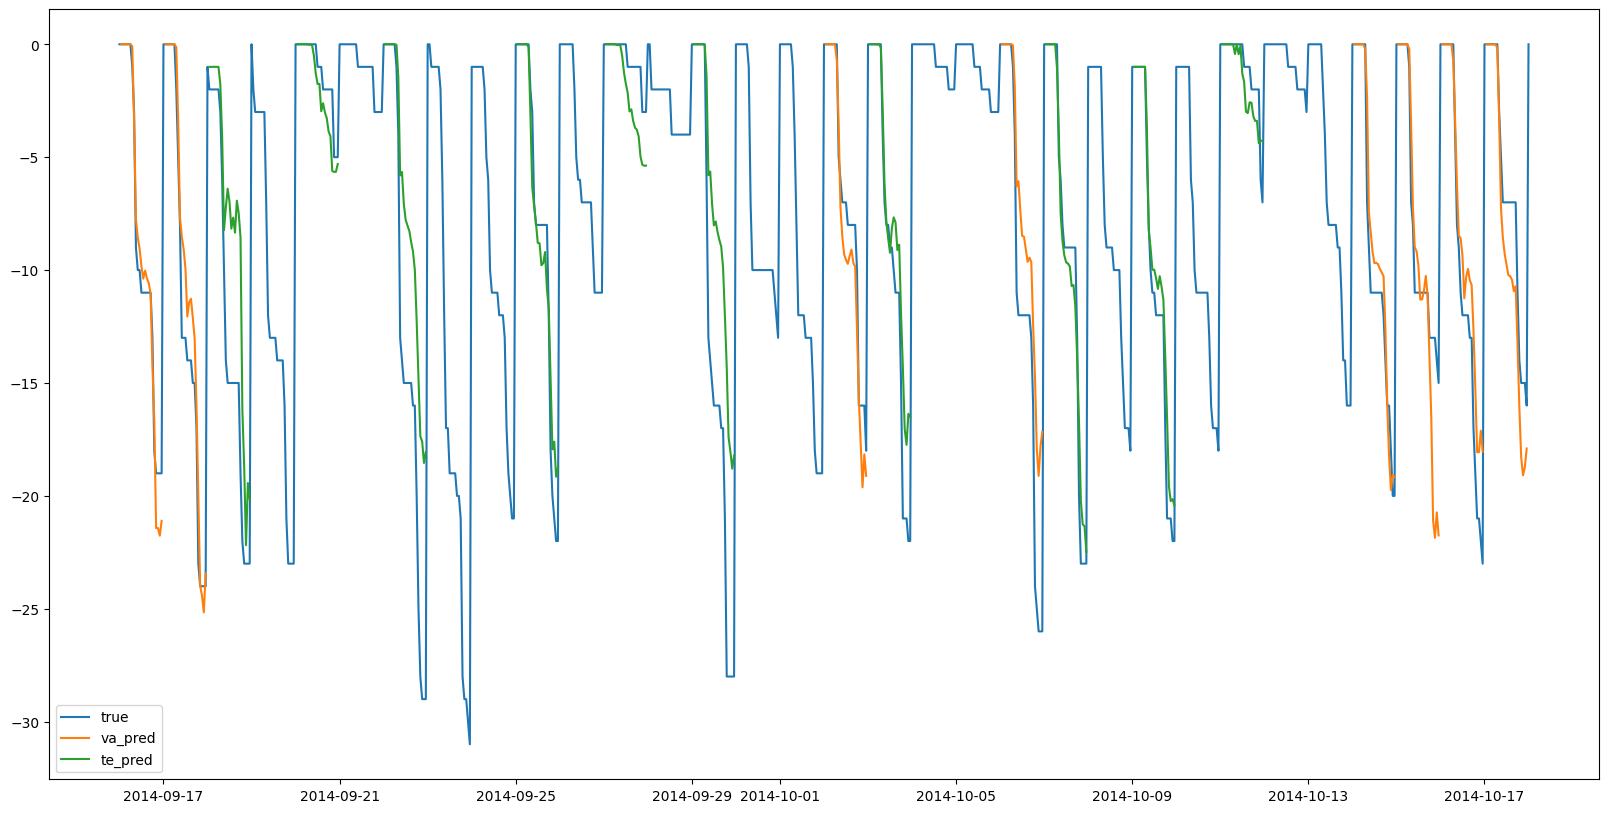

In [83]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル demand_cumsum


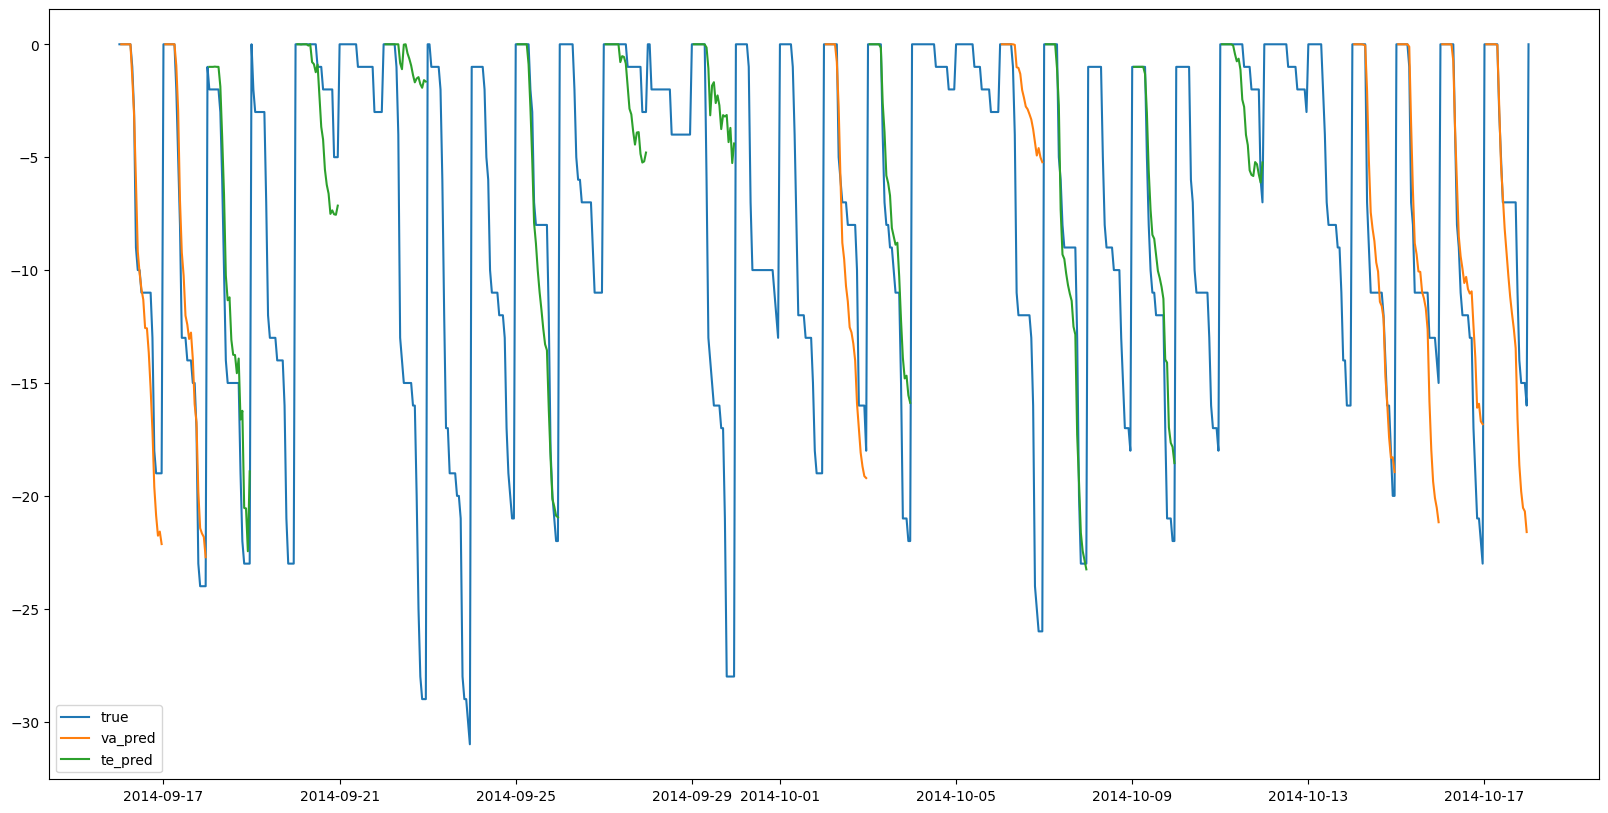

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_供給

In [84]:
df_main_lgb_supply = load_feature("df_key")
df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_supply_cumsum"), on=["station_id", "datetime"], how="left")
df_main_lgb_supply = pd.merge(df_main_lgb_supply, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_demand = pd.merge(df_main_lgb_demand, load_feature("df_datetime_atr"), on=["datetime"], how="left")

In [85]:
df_main_lgb_supply.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_supply.pkl"))

In [ ]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [86]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_supply")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_supply_202410210121'

In [87]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)

    return df_pred

model_params_lgb_supply = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_supply = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_supply = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [88]:
memo = "LightGBM23期マルチモデル supply_cumsum"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_supply,
    df_main_lgb_supply,
    run_setting_lgb_supply,
    cv_setting_lgb_supply,
    logger,
    memo)

In [89]:
ml_runner.run_train_cv()

[2024-10-21 01:21:07] - lgbm_multiml_supply_202410210121 - start training cv
[2024-10-21 01:21:07] - lgbm_multiml_supply_202410210121 fold 2014-09-01 - start training


term: 1, tr_x: (23380, 25), tr_y: (23380, 1), va_x: (2170, 25), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 23380, number of used features: 25
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0995927	eval's l1: 0.117829
[200]	train's l1: 0.082551	eval's l1: 0.0992223
[300]	train's l1: 0.0763132	eval's l1: 0.0924116
[400]	train's l1: 0.07403	eval's l1: 0.0899186
[500]	train's l1: 0.0731942	eval's l1: 0.0890061
[600]	train's l1: 0.0728883	eval's l1: 0.0886721
[700]	train's l1: 0.0727764	eval's l1: 0.0885498
[800]	train's l1: 0.0727354	eval's l1: 0.0885051
[900]	train's l1: 0.0727204	eval's l1: 0.0884887
[1000]	train's l1: 0.0727149	eval's l1: 0.0884827
[1100]	train's l1: 

[2024-10-21 01:22:18] - lgbm_multiml_supply_202410210121 fold 2014-09-01 - end training
[2024-10-21 01:22:18] - lgbm_multiml_supply_202410210121 fold 2014-10-01 - start training


term: 1, tr_x: (25550, 25), tr_y: (25550, 1), va_x: (420, 25), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 373
[LightGBM] [Info] Number of data points in the train set: 25550, number of used features: 25
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.101142	eval's l1: 0.109245
[200]	train's l1: 0.0839669	eval's l1: 0.0943273
[300]	train's l1: 0.0776805	eval's l1: 0.0888669
[400]	train's l1: 0.0753794	eval's l1: 0.0868682
[500]	train's l1: 0.0745372	eval's l1: 0.0861367
[600]	train's l1: 0.0742289	eval's l1: 0.0858689
[700]	train's l1: 0.074116	eval's l1: 0.0857709
[800]	train's l1: 0.0740747	eval's l1: 0.085735
[900]	train's l1: 0.0740596	eval's l1: 0.0857219
[1000]	train's l1: 0.0740541	eval's l1: 0.0857171
[1100]	train's l1: 0.

[2024-10-21 01:23:34] - lgbm_multiml_supply_202410210121 fold 2014-10-01 - end training
[2024-10-21 01:23:34] - lgbm_multiml_supply_202410210121 fold 2014-11-01 - start training


...

[2024-10-21 01:36:14] - lgbm_multiml_supply_202410210121 fold 2015-06-01 - end training
[2024-10-21 01:36:14] - lgbm_multiml_supply_202410210121 fold 2015-07-01 - start training


term: 1, tr_x: (44660, 25), tr_y: (44660, 1), va_x: (280, 25), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003866 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 411
[LightGBM] [Info] Number of data points in the train set: 44660, number of used features: 25
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0990134	eval's l1: 0.0459161
[200]	train's l1: 0.0815965	eval's l1: 0.032656
[300]	train's l1: 0.0752213	eval's l1: 0.0278023
[400]	train's l1: 0.0728878	eval's l1: 0.0260257
[500]	train's l1: 0.0720337	eval's l1: 0.0253755
[600]	train's l1: 0.071721	eval's l1: 0.0251374
[700]	train's l1: 0.0716066	eval's l1: 0.0250503
[800]	train's l1: 0.0715647	eval's l1: 0.0250184
[900]	train's l1: 0.0715494	eval's l1: 0.0250067
[1000]	train's l1: 0.0715438	eval's l1: 0.0250025
[1100]	train's l1: 

[2024-10-21 01:40:23] - lgbm_multiml_supply_202410210121 fold 2015-07-01 - end training
[2024-10-21 01:40:23] - lgbm_multiml_supply_202410210121 fold 2015-08-01 - start training


term: 1, tr_x: (46760, 25), tr_y: (46760, 1), va_x: (350, 25), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004477 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 414
[LightGBM] [Info] Number of data points in the train set: 46760, number of used features: 25
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0981356	eval's l1: 0.0986195
[200]	train's l1: 0.080811	eval's l1: 0.0813813
[300]	train's l1: 0.0744697	eval's l1: 0.0750716
[400]	train's l1: 0.0721485	eval's l1: 0.072762
[500]	train's l1: 0.0712989	eval's l1: 0.0719167
[600]	train's l1: 0.0709879	eval's l1: 0.0716072
[700]	train's l1: 0.0708741	eval's l1: 0.071494
[800]	train's l1: 0.0708324	eval's l1: 0.0714525
[900]	train's l1: 0.0708172	eval's l1: 0.0714373
[1000]	train's l1: 0.0708116	eval's l1: 0.0714318
[1100]	train's l1: 0

[2024-10-21 01:43:40] - lgbm_multiml_supply_202410210121 fold 2015-08-01 - end training
[2024-10-21 01:43:40] - lgbm_multiml_supply_202410210121 - end training cv


In [90]:
ml_runner.run_metric_cv()

[2024-10-21 01:43:40] - lgbm_multiml_supply_202410210121 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

(10080, 29)


  8%|▊         | 1/12 [00:15<02:47, 15.23s/it]

(10080, 29)


 17%|█▋        | 2/12 [00:29<02:27, 14.77s/it]

...

 83%|████████▎ | 10/12 [02:22<00:28, 14.01s/it]

(8400, 29)


 92%|█████████▏| 11/12 [02:36<00:14, 14.17s/it]

(8400, 29)


100%|██████████| 12/12 [02:50<00:00, 14.24s/it]
memo: LightGBM23期マルチモデル supply_cumsum
run_name:lgbm_multiml_supply_202410210121	score_mean:2.941577816594181	score0:3.2593239018454145	score1:2.8575351840930234	score2:3.3731870285988275	score3:2.0594579474004475	score4:2.462696367232264	score5:3.318616131598481	score6:3.389138005681933	score7:2.4101587080714575	score8:2.1925277564622605	score9:3.607273237982907	score10:3.5457018027695795	score11:2.823317727393573
mean: 2.941577816594181, std: 0.5251846552705048
[2024-10-21 01:46:31] - mean: 2.941577816594181, std: 0.5251846552705048
[2024-10-21 01:46:31] - output predict : ../models/lgbm_multiml_supply_202410210121/va_pred.pkl
[2024-10-21 01:46:31] - lgbm_multiml_supply_202410210121 - end metric cv


In [91]:
ml_runner.run_predict_cv()

[2024-10-21 01:46:31] - lgbm_multiml_supply_202410210121 - start prediction cv
100%|██████████| 12/12 [02:50<00:00, 14.25s/it]
[2024-10-21 01:49:22] - output predict : ../models/lgbm_multiml_supply_202410210121/te_pred.pkl
[2024-10-21 01:49:22] - lgbm_multiml_supply_202410210121 - end prediction cv


In [92]:
ml_runner.plot_feature_importance_cv()

[2024-10-21 01:49:22] - lgbm_multiml_supply_202410210121 - start plot feature importance cv
[2024-10-21 01:49:55] - lgbm_multiml_supply_202410210121 - end plot feature importance cv


In [93]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_lgb_supply[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル supply_cumsum


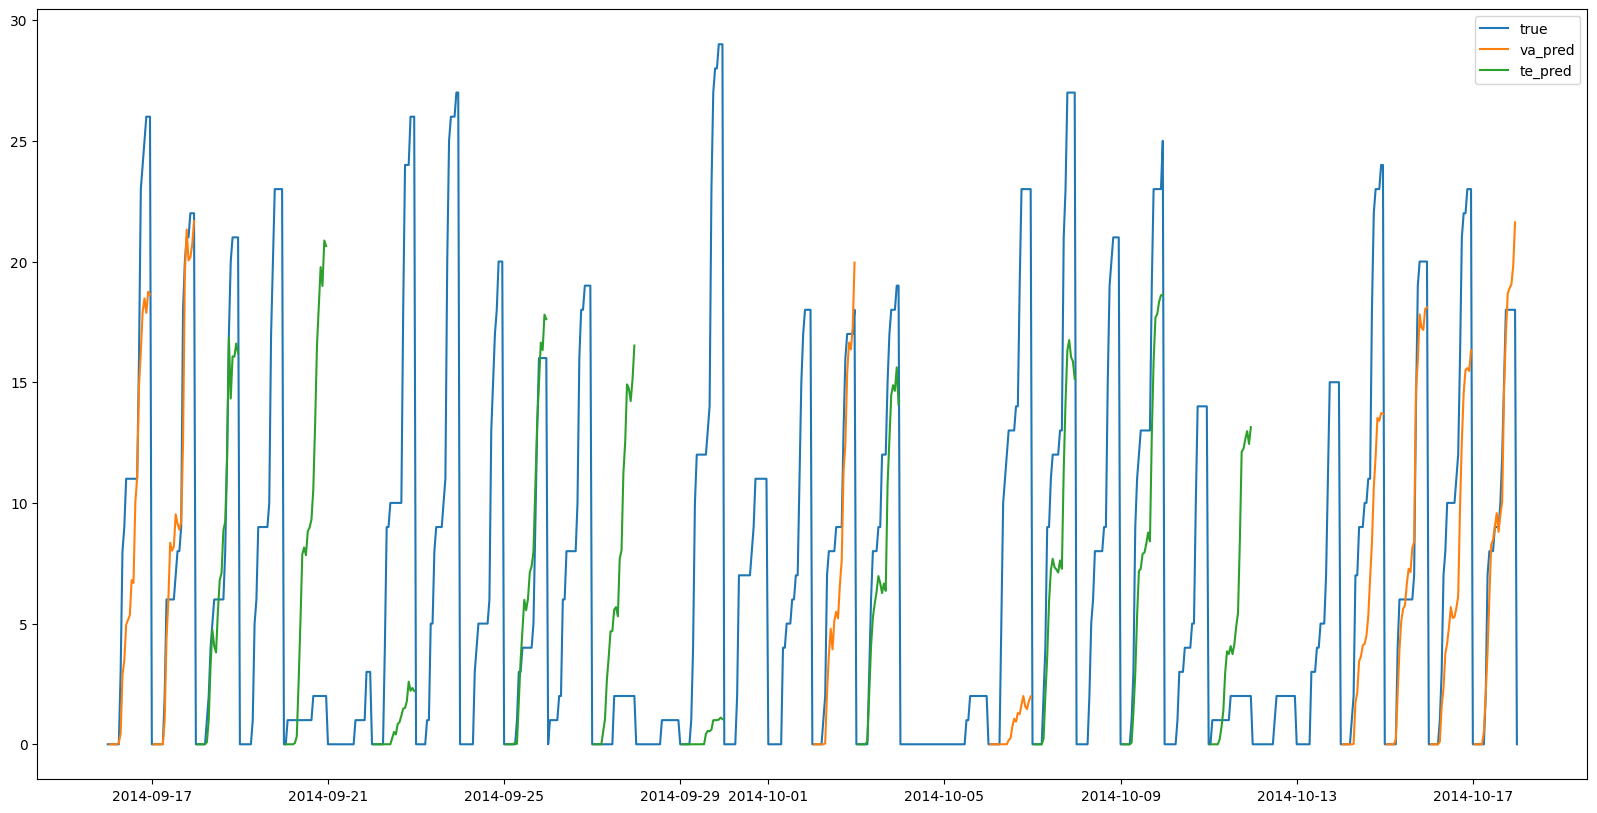

In [94]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル demand_supply


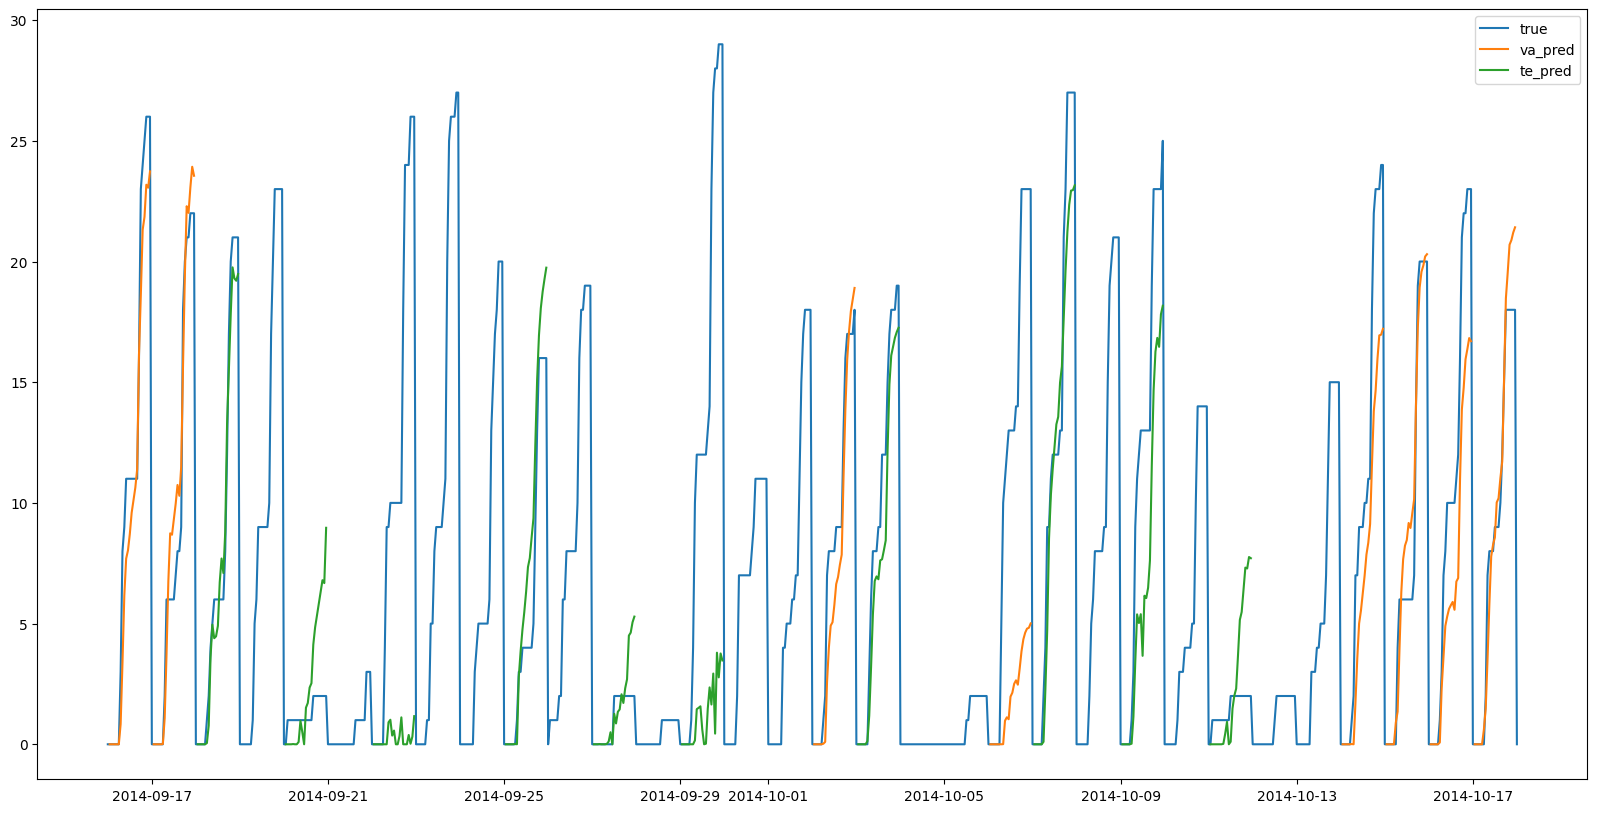

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_介入

In [96]:
df_main_lgb_intervention = load_feature("df_key")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_intervention_cumsum"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_demand_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_supply_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_intervention_lag"), on=["station_id", "datetime"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_station_atr"), on=["station_id"], how="left")
df_main_lgb_intervention = pd.merge(df_main_lgb_intervention, load_feature("df_datetime_atr"), on=["datetime"], how="left")

In [97]:
df_main_lgb_intervention.to_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_intervention.pkl"))

In [ ]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [98]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_intervention")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_intervention_202410210921'

In [99]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """

    return df_pred

model_params_lgb_intervention = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_intervention = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_intervention = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [100]:
memo = "LightGBM23期マルチモデル intervention_cumsum"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel,
    model_params_lgb_intervention,
    df_main_lgb_intervention,
    run_setting_lgb_intervention,
    cv_setting_lgb_intervention,
    logger,
    memo)

In [101]:
ml_runner.run_train_cv()

[2024-10-21 09:21:35] - lgbm_multiml_intervention_202410210921 - start training cv
[2024-10-21 09:21:35] - lgbm_multiml_intervention_202410210921 fold 2014-09-01 - start training


term: 1, tr_x: (22476, 94), tr_y: (22476, 1), va_x: (2170, 94), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1848
[LightGBM] [Info] Number of data points in the train set: 22476, number of used features: 93
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0719801	eval's l1: 0.0827252
[200]	train's l1: 0.068258	eval's l1: 0.078822
[300]	train's l1: 0.0668734	eval's l1: 0.077642
[400]	train's l1: 0.0661562	eval's l1: 0.0771501
[500]	train's l1: 0.0656333	eval's l1: 0.076986
[600]	train's l1: 0.0654755	eval's l1: 0.0768984
Early stopping, best iteration is:
[589]	train's l1: 0.0654945	eval's l1: 0.0768934
term: 2, tr_x: (22476, 94), tr_y: (22476, 1), va_x: (2170, 94), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-thre

[2024-10-21 09:23:57] - lgbm_multiml_intervention_202410210921 fold 2014-09-01 - end training
[2024-10-21 09:23:57] - lgbm_multiml_intervention_202410210921 fold 2014-10-01 - start training


term: 1, tr_x: (24646, 94), tr_y: (24646, 1), va_x: (420, 94), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008574 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1896
[LightGBM] [Info] Number of data points in the train set: 24646, number of used features: 93
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0721613	eval's l1: 0.658126
[200]	train's l1: 0.0678512	eval's l1: 0.644309
[300]	train's l1: 0.0662176	eval's l1: 0.639087
[400]	train's l1: 0.0655458	eval's l1: 0.637565
[500]	train's l1: 0.064942	eval's l1: 0.625733
[600]	train's l1: 0.0644752	eval's l1: 0.605374
[700]	train's l1: 0.064242	eval's l1: 0.597851
[800]	train's l1: 0.0641359	eval's l1: 0.595214
[900]	train's l1: 0.0640714	eval's l1: 0.594174
[1000]	train's l1: 0.0640007	eval's l1: 0.594109
[1100]	train's l1: 0.0639327

[2024-10-21 09:25:47] - lgbm_multiml_intervention_202410210921 fold 2014-10-01 - end training
[2024-10-21 09:25:47] - lgbm_multiml_intervention_202410210921 fold 2014-11-01 - start training


...

[2024-10-21 09:44:45] - lgbm_multiml_intervention_202410210921 fold 2015-06-01 - end training
[2024-10-21 09:44:45] - lgbm_multiml_intervention_202410210921 fold 2015-07-01 - start training


term: 1, tr_x: (37456, 94), tr_y: (37456, 1), va_x: (280, 94), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1994
[LightGBM] [Info] Number of data points in the train set: 37456, number of used features: 93
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0872784	eval's l1: 0.0539968
[200]	train's l1: 0.0804579	eval's l1: 0.0505584
[300]	train's l1: 0.0764591	eval's l1: 0.0500948
[400]	train's l1: 0.0744966	eval's l1: 0.0500059
[500]	train's l1: 0.074192	eval's l1: 0.0498801
[600]	train's l1: 0.0740805	eval's l1: 0.0498341
[700]	train's l1: 0.0740397	eval's l1: 0.0498172
[800]	train's l1: 0.0740247	eval's l1: 0.0498111
[900]	train's l1: 0.0740193	eval's l1: 0.0498088
[1000]	train's l1: 0.0740173	eval's l1: 0.049808
[1100]	train's l1:

[2024-10-21 09:47:21] - lgbm_multiml_intervention_202410210921 fold 2015-07-01 - end training
[2024-10-21 09:47:21] - lgbm_multiml_intervention_202410210921 fold 2015-08-01 - start training


term: 1, tr_x: (38856, 94), tr_y: (38856, 1), va_x: (350, 94), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008851 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1998
[LightGBM] [Info] Number of data points in the train set: 38856, number of used features: 93
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0866712	eval's l1: 0.0677771
[200]	train's l1: 0.0795305	eval's l1: 0.0670512
Early stopping, best iteration is:
[141]	train's l1: 0.0830044	eval's l1: 0.0668843
term: 2, tr_x: (38856, 94), tr_y: (38856, 1), va_x: (350, 94), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008609 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tot

[2024-10-21 09:49:20] - lgbm_multiml_intervention_202410210921 fold 2015-08-01 - end training
[2024-10-21 09:49:20] - lgbm_multiml_intervention_202410210921 - end training cv


In [102]:
ml_runner.run_metric_cv()

[2024-10-21 09:49:20] - lgbm_multiml_intervention_202410210921 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

(10080, 98)


  8%|▊         | 1/12 [00:20<03:46, 20.60s/it]

(10080, 98)


 17%|█▋        | 2/12 [00:39<03:15, 19.54s/it]

...

 83%|████████▎ | 10/12 [03:08<00:37, 18.72s/it]

(8400, 98)


 92%|█████████▏| 11/12 [03:27<00:18, 18.80s/it]

(8400, 98)


100%|██████████| 12/12 [03:45<00:00, 18.81s/it]
memo: LightGBM23期マルチモデル intervention_cumsum
run_name:lgbm_multiml_intervention_202410210921	score_mean:1.8282668777678088	score0:3.687946748245264	score1:2.2300005738417537	score2:1.9985529137267524	score3:1.2818457695143204	score4:1.6204529260163925	score5:1.5937589837214385	score6:1.4596330580034889	score7:1.5461693937914347	score8:1.4774768391864932	score9:1.9085734606868257	score10:1.6086053837888832	score11:1.5261864826906586
mean: 1.8282668777678088, std: 0.6144122906428093
[2024-10-21 09:53:06] - mean: 1.8282668777678088, std: 0.6144122906428093
[2024-10-21 09:53:06] - output predict : ../models/lgbm_multiml_intervention_202410210921/va_pred.pkl
[2024-10-21 09:53:06] - lgbm_multiml_intervention_202410210921 - end metric cv


In [103]:
ml_runner.run_predict_cv()

[2024-10-21 09:53:06] - lgbm_multiml_intervention_202410210921 - start prediction cv
100%|██████████| 12/12 [04:01<00:00, 20.09s/it]
[2024-10-21 09:57:07] - output predict : ../models/lgbm_multiml_intervention_202410210921/te_pred.pkl
[2024-10-21 09:57:07] - lgbm_multiml_intervention_202410210921 - end prediction cv


In [104]:
ml_runner.plot_feature_importance_cv()

[2024-10-21 09:57:07] - lgbm_multiml_intervention_202410210921 - start plot feature importance cv
[2024-10-21 09:57:53] - lgbm_multiml_intervention_202410210921 - end plot feature importance cv


In [105]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_lgb_intervention[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル intervention_cumsum


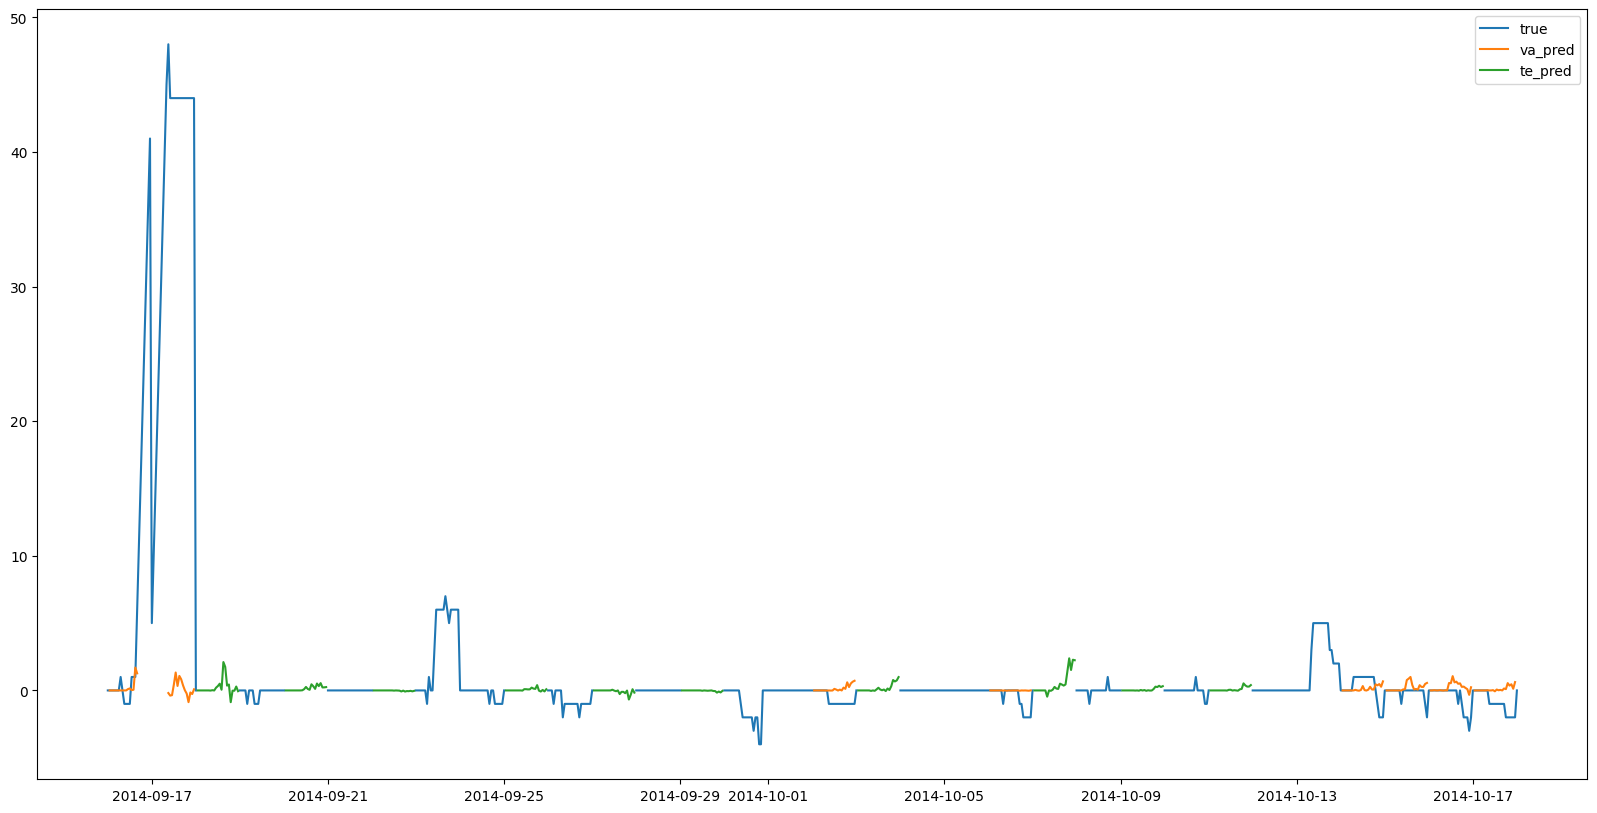

In [106]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル intervention_cumsum


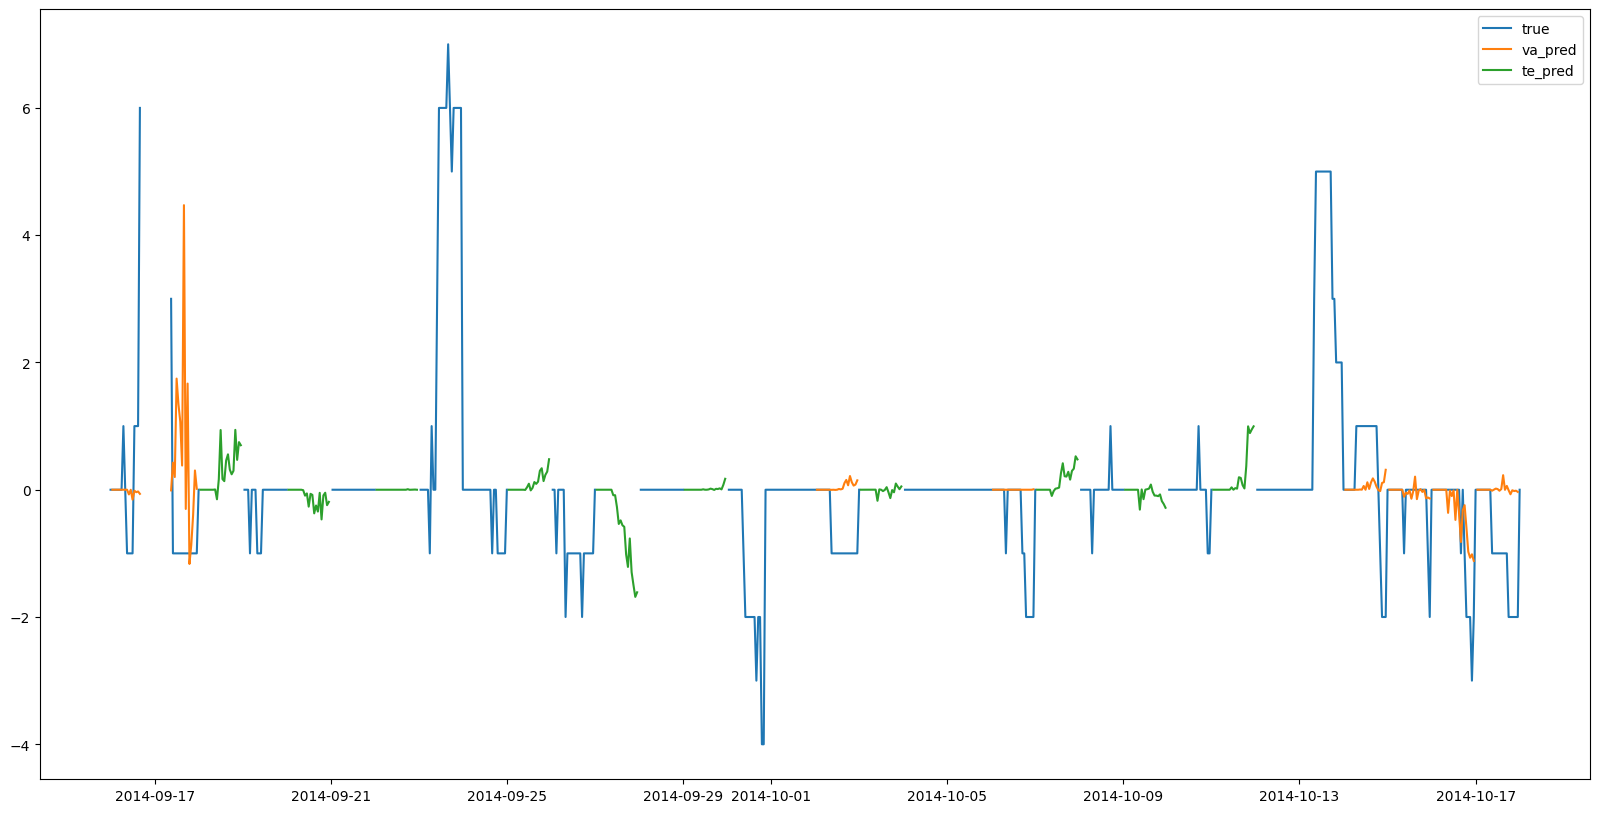

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# 需要＋供給＋介入

In [130]:
def after_predict_process(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [132]:
de_run_name = "lgbm_multiml_demand_202410210031"
de_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "va_pred.pkl"))
de_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "te_pred.pkl"))
de_va_te_pred = pd.concat([de_va_pred, de_te_pred], axis=0)
# de_va_te_pred = de_va_te_pred.drop(columns=["target"])

In [133]:
su_run_name = "lgbm_multiml_supply_202410210121"
su_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "va_pred.pkl"))
su_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "te_pred.pkl"))
su_va_te_pred = pd.concat([su_va_pred, su_te_pred], axis=0)
# su_va_te_pred = su_va_te_pred.drop(columns=["target"])

In [134]:
in_run_name = "lgbm_multiml_intervention_202410210921"
in_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "va_pred.pkl"))
in_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "te_pred.pkl"))
in_va_te_pred = pd.concat([in_va_pred, in_te_pred], axis=0)
# in_va_te_pred = in_va_te_pred.drop(columns=["target"])

In [135]:
df_target = load_feature("df_target")
df_true_00 = df_target[df_target["datetime"].dt.hour==0][["station_id", "datetime", "bikes_available"]].copy()
df_true_00["date"] = df_true_00["datetime"].dt.date
df_true_00 = df_true_00.rename(columns={"bikes_available": "bikes_available_00"})
df_true_00 = df_true_00[["station_id", "date", "bikes_available_00"]]
df_pred = load_feature("df_key")
df_pred["date"] = df_pred["datetime"].dt.date
df_pred = pd.merge(df_pred, df_true_00, on=["station_id", "date"], how="left")
df_pred = df_pred[["station_id", "datetime", "bikes_available_00"]]

df_pred = df_pred.copy()
df_pred = pd.merge(df_pred, load_feature("df_predict_add_valid_flag"), on=["station_id","datetime"], how="left")
df_pred = pd.merge(df_pred, de_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_de_va_pred"))
df_pred = pd.merge(df_pred, su_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_su_va_pred"))
df_pred = pd.merge(df_pred, in_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_in_va_pred"))

df_true = df_target[["station_id", "datetime", "bikes_available"]].copy()
df_true = pd.merge(df_true, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")

In [136]:
df_pred["bikes_available"] = df_pred["bikes_available_00"] + df_pred["demand_cumsum"] + df_pred["supply_cumsum"] + df_pred["intervention_cumsum"]

In [137]:
df_metric = pd.merge(df_true, df_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_pred"))
df_metric = df_metric.dropna(subset=["bikes_available", "bikes_available_pred"])
df_metric = df_metric[df_metric["predict"]==2]
df_metric = df_metric.sort_values(["station_id", "datetime"])

In [140]:
df_metric.head()

,station_id,datetime,bikes_available,predict,bikes_available_00,predict_pred,demand_cumsum,supply_cumsum,intervention_cumsum,bikes_available_pred
8953,0,2014-09-09 01:00:00,10.0,2,10.0,2,0.0000,0.0,0.0,10.0000
8954,0,2014-09-09 02:00:00,10.0,2,10.0,2,-0.0099,0.0,0.0,9.9901
8955,0,2014-09-09 03:00:00,10.0,2,10.0,2,0.0000,0.0,0.0,10.0000
8956,0,2014-09-09 04:00:00,10.0,2,10.0,2,0.0000,0.0,0.0,10.0000
8957,0,2014-09-09 05:00:00,10.0,2,10.0,2,0.0000,0.0,0.0,10.0000


In [138]:
from sklearn.metrics import mean_absolute_error
def metric(va_true, va_pred):
    """評価指標の計算
    """
    score = mean_absolute_error(va_true, va_pred)
    # score = math.sqrt(mean_squared_error(va_true, va_pred))

    return score

metric(df_metric["bikes_available"].values,
       df_metric["bikes_available_pred"].values)

2.8180898633020757

# LGBM_需要＋供給＋介入

In [127]:
df_main_lgb_ans = load_feature("df_key")
df_main_lgb_ans = pd.merge(df_main_lgb_ans, load_feature("df_predict_add_valid_flag"), on=["station_id", "datetime"], how="left")
df_main_lgb_ans = pd.merge(df_main_lgb_ans, load_feature("df_bikes_available_fillna"), on=["station_id", "datetime"], how="left")
df_main_lgb_ans = pd.merge(df_main_lgb_ans, pd.read_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_demand.pkl")), on=["station_id", "datetime"], how="left", suffixes=('', '_dem'))
df_main_lgb_ans = pd.merge(df_main_lgb_ans, pd.read_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_supply.pkl")), on=["station_id", "datetime"], how="left", suffixes=('', '_sup'))
df_main_lgb_ans = pd.merge(df_main_lgb_ans, pd.read_pickle(os.path.join(DIR_FEATURE, "df_main_lgb_intervention.pkl")), on=["station_id", "datetime"], how="left", suffixes=('', '_int'))

In [147]:
import importlib
from src import runner
from src import model_LGBM
from src import model_ASMBL
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model_ASMBL)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_LSTM_mult import model_LSTM_mult
from src.model_ASMBL import model_ASMBL_demand_supply_intervention

In [110]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="ansamble_lgbm")
# run_name = 'ansamble_lgbm_202410162243'
run_name

'ansamble_lgbm_202410210959'

In [117]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # pred model params
    "demand_model_cls": model_LGBM_multimodel,
    "supply_model_cls": model_LGBM_multimodel,
    "intervention_model_cls": model_LGBM_multimodel,
    "demand_run_name": "lgbm_multiml_demand_202410210031",
    "supply_run_name": "lgbm_multiml_supply_202410210121",
    "intervention_run_name": "lgbm_multiml_intervention_202410210921",
    # ans model run params
    "num_boost_round": 3000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # ans model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [148]:
memo = "アンサンブルLGBM ベースライン"
ml_runner = MLModelRunner(
    run_name,
    model_ASMBL_demand_supply_intervention,
    model_params_lgb,
    df_main_lgb_ans,
    run_setting,
    cv_setting,
    logger,
    memo)

In [119]:
ml_runner.run_train_cv()

[2024-10-21 10:05:01] - ansamble_lgbm_202410210959 - start training cv
[2024-10-21 10:05:01] - ansamble_lgbm_202410210959 fold 2014-09-01 - start training


(587650, 3)
(587650, 3)
(587650, 3)
(563546, 25)
(463772, 23) (463772,) (99774, 23) (99774,)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1380
[LightGBM] [Info] Number of data points in the train set: 463772, number of used features: 23
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.95317	eval's l1: 2.11016
[200]	train's l1: 1.67344	eval's l1: 1.79903
[300]	train's l1: 1.56309	eval's l1: 1.65537
[400]	train's l1: 1.50594	eval's l1: 1.58785
[500]	train's l1: 1.48335	eval's l1: 1.55995
[600]	train's l1: 1.47221	eval's l1: 1.54547
[700]	train's l1: 1.46779	eval's l1: 1.53946
[800]	train's l1: 1.46624	eval's l1: 1.53676
[900]	train's l1: 1.46587	eval's l1: 1.53613
[1000]	train's l1: 1.46576	eval's

[2024-10-21 10:07:32] - ansamble_lgbm_202410210959 fold 2014-09-01 - end training
[2024-10-21 10:07:32] - ansamble_lgbm_202410210959 fold 2014-10-01 - start training


(635950, 3)
(635950, 3)
(635950, 3)
(610236, 25)
(513682, 23) (513682,) (96554, 23) (96554,)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012005 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1384
[LightGBM] [Info] Number of data points in the train set: 513682, number of used features: 23
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.96325	eval's l1: 3.19861
[200]	train's l1: 1.6771	eval's l1: 2.94898
[300]	train's l1: 1.55955	eval's l1: 2.8197
[400]	train's l1: 1.5175	eval's l1: 2.77691
[500]	train's l1: 1.49703	eval's l1: 2.75894
[600]	train's l1: 1.48695	eval's l1: 2.75114
[700]	train's l1: 1.48016	eval's l1: 2.7451
[800]	train's l1: 1.47572	eval's l1: 2.73872
[900]	train's l1: 1.47457	eval's l1: 2.73701
[1000]	train's l1: 1.47411	eval's l1:

[2024-10-21 10:10:06] - ansamble_lgbm_202410210959 fold 2014-10-01 - end training
[2024-10-21 10:10:06] - ansamble_lgbm_202410210959 fold 2014-11-01 - start training


...

[2024-10-21 10:28:43] - ansamble_lgbm_202410210959 fold 2015-06-01 - end training
[2024-10-21 10:28:43] - ansamble_lgbm_202410210959 fold 2015-07-01 - start training


(1075480, 3)
(1075480, 3)
(1075480, 3)
(1049674, 25)
(951533, 23) (951533,) (98141, 23) (98141,)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1398
[LightGBM] [Info] Number of data points in the train set: 951533, number of used features: 23
[LightGBM] [Info] Start training from score 7.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 2.84455	eval's l1: 3.94652
[200]	train's l1: 2.59145	eval's l1: 3.74416
[300]	train's l1: 2.46878	eval's l1: 3.61349
[400]	train's l1: 2.39342	eval's l1: 3.55751
Early stopping, best iteration is:
[391]	train's l1: 2.39937	eval's l1: 3.55581


[2024-10-21 10:31:45] - ansamble_lgbm_202410210959 fold 2015-07-01 - end training
[2024-10-21 10:31:45] - ansamble_lgbm_202410210959 fold 2015-08-01 - start training


(1125390, 3)
(1125390, 3)
(1125390, 3)
(1097974, 25)
(1001443, 23) (1001443,) (96531, 23) (96531,)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1398
[LightGBM] [Info] Number of data points in the train set: 1001443, number of used features: 23
[LightGBM] [Info] Start training from score 7.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 2.89347	eval's l1: 3.90518
[200]	train's l1: 2.6173	eval's l1: 3.70105
[300]	train's l1: 2.50835	eval's l1: 3.59533
[400]	train's l1: 2.42462	eval's l1: 3.54841
[500]	train's l1: 2.3894	eval's l1: 3.54611
[600]	train's l1: 2.37283	eval's l1: 3.53358
[700]	train's l1: 2.36713	eval's l1: 3.52688
[800]	train's l1: 2.3652	eval's l1: 3.5229
[900]	train's l1: 2.36377	eval's l1: 3.5227
[1000]	train's l1: 2.36132	eval

[2024-10-21 10:34:19] - ansamble_lgbm_202410210959 fold 2015-08-01 - end training
[2024-10-21 10:34:19] - パラメータは保存しません
[2024-10-21 10:34:19] - ansamble_lgbm_202410210959 - end training cv


In [149]:
ml_runner.run_metric_cv()

[2024-10-21 21:09:18] - ansamble_lgbm_202410210959 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

2014-09-01 00:00:00
(9660, 3)
(9660, 3)
(9660, 3)
(9660, 25)


  8%|▊         | 1/12 [00:40<07:28, 40.78s/it]

(8680, 3) (8680, 4)
2014-10-01 00:00:00
(9660, 3)
(9660, 3)
(9660, 3)
(9660, 25)


 17%|█▋        | 2/12 [01:21<06:44, 40.46s/it]

(9660, 3) (9660, 4)
2014-11-01 00:00:00
(11270, 3)
(11270, 3)
(11270, 3)
(11270, 25)


 25%|██▌       | 3/12 [02:05<06:19, 42.22s/it]

(11270, 3) (11270, 4)
2014-12-01 00:00:00


 25%|██▌       | 3/12 [02:20<07:01, 46.81s/it]


KeyboardInterrupt: 

In [121]:
ml_runner.run_predict_cv()

[2024-10-21 10:43:32] - ansamble_lgbm_202410210959 - start prediction cv
  0%|          | 0/12 [00:00<?, ?it/s]

(16100, 3)
(16100, 3)
(16100, 3)
(16100, 25)


  8%|▊         | 1/12 [00:41<07:41, 41.99s/it]

(16100, 3)
(16100, 3)
(16100, 3)
(16100, 25)


 17%|█▋        | 2/12 [01:20<06:38, 39.88s/it]

...

 83%|████████▎ | 10/12 [06:29<01:18, 39.39s/it]

(16100, 3)
(16100, 3)
(16100, 3)
(14490, 25)


 92%|█████████▏| 11/12 [07:08<00:39, 39.42s/it]

(16100, 3)
(16100, 3)
(16100, 3)
(16100, 25)


100%|██████████| 12/12 [07:47<00:00, 38.97s/it]
[2024-10-21 10:51:20] - output predict : ../models/ansamble_lgbm_202410210959/te_pred.pkl
[2024-10-21 10:51:20] - ansamble_lgbm_202410210959 - end prediction cv


In [150]:
ml_runner.plot_feature_importance_cv()

[2024-10-21 21:11:41] - ansamble_lgbm_202410210959 - start plot feature importance cv
[2024-10-21 21:12:11] - ansamble_lgbm_202410210959 - end plot feature importance cv


In [141]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

アンサンブルLGBM ベースライン


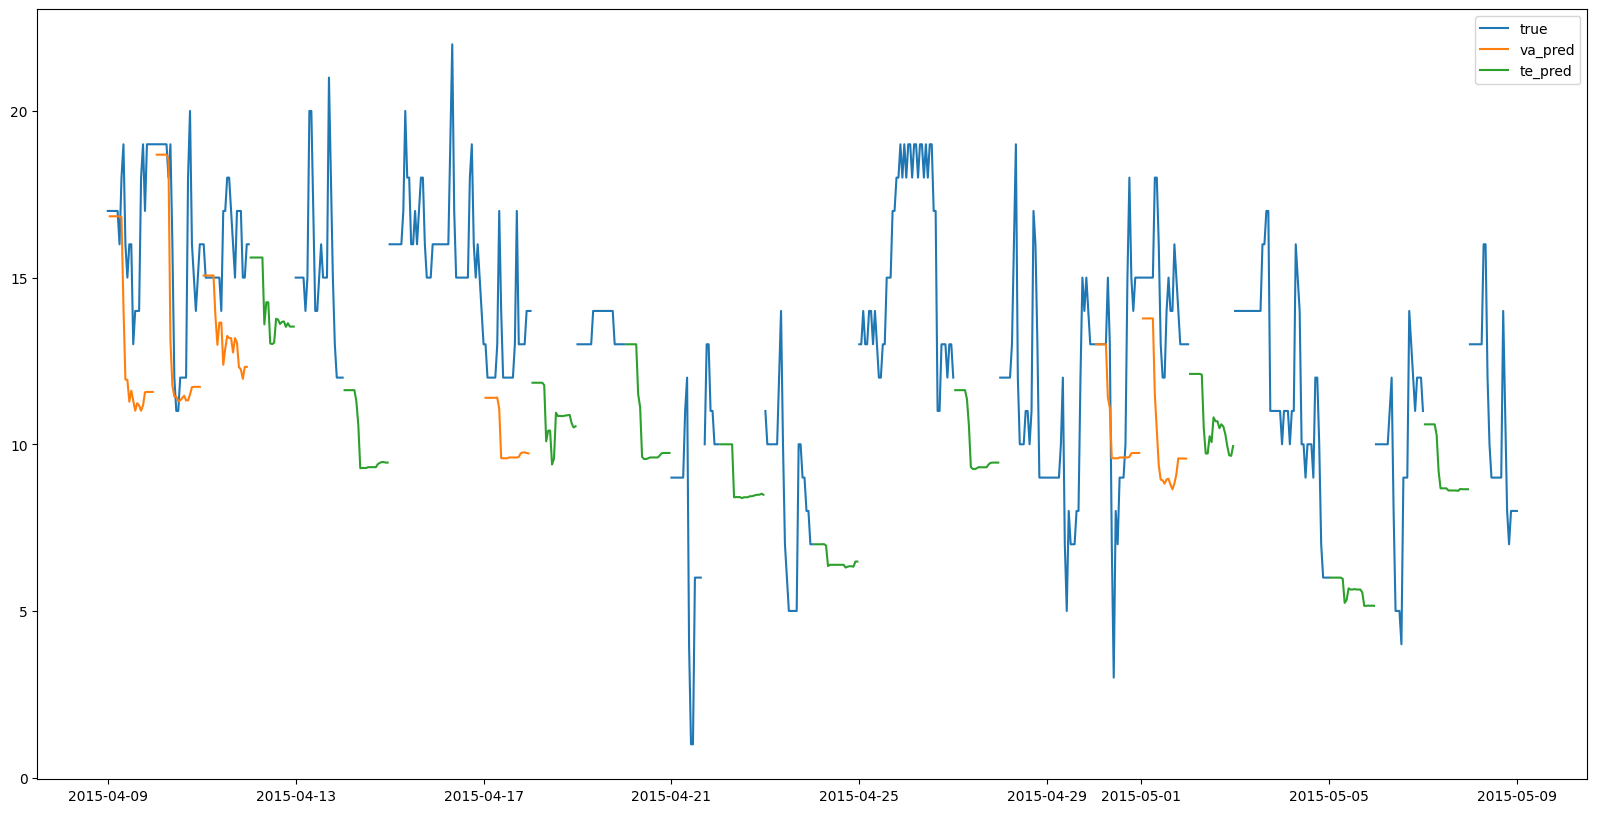

In [142]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

アンサンブルLGBM ベースライン


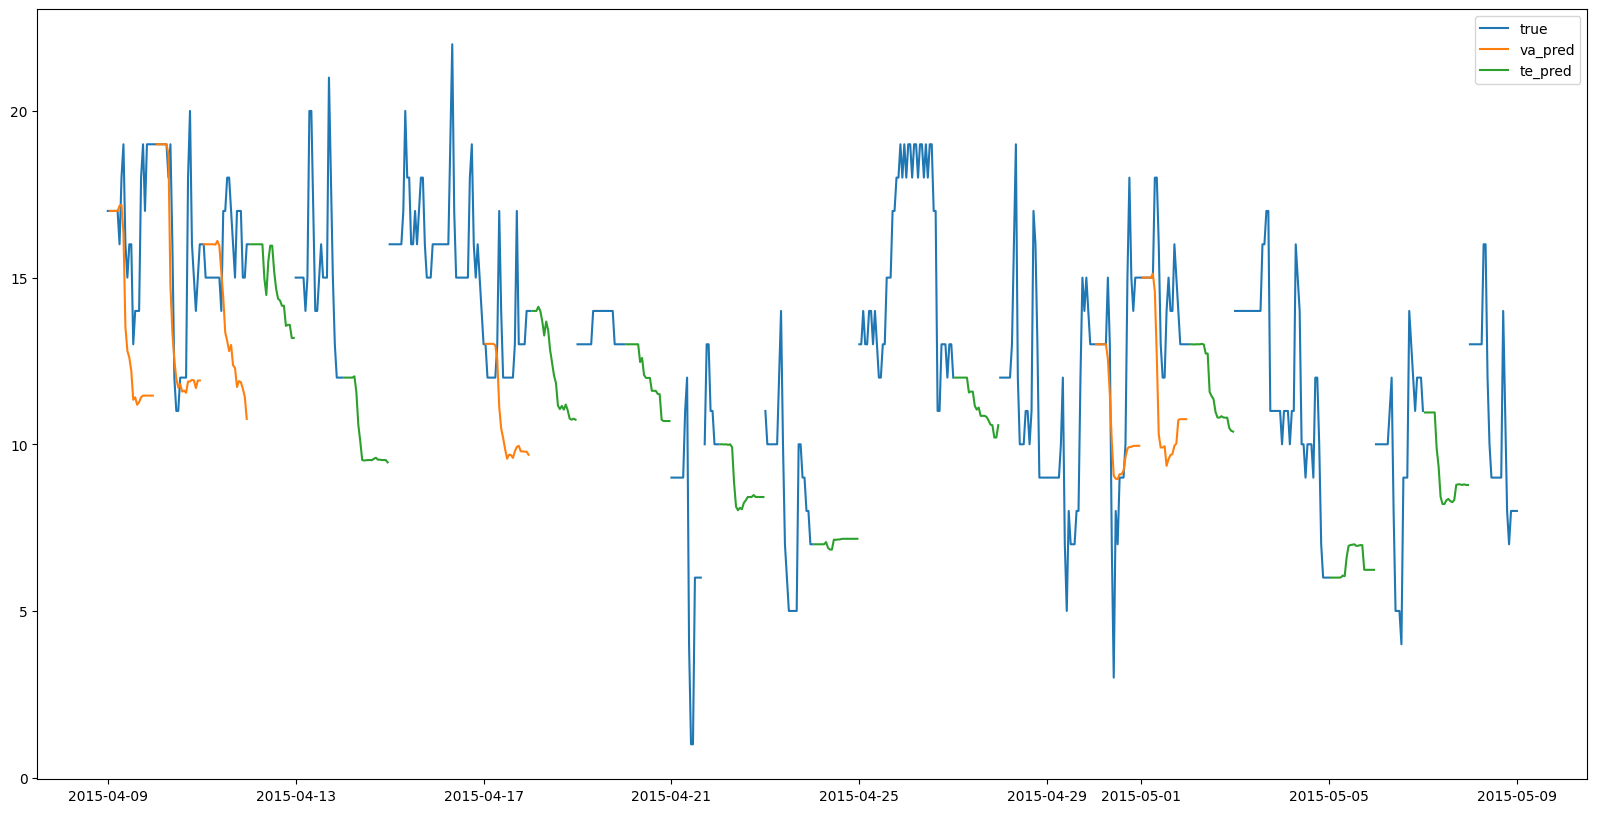

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# Submissionの作成

In [40]:
runner = ml_runner

In [41]:
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_te_pred = pd.read_pickle(path_te_pred)
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["id", "datetime", "station_id", "predict"]]

In [42]:
df_submit = pd.merge(df_prep_status, df_te_pred, on=["datetime", "station_id"], how="left")

In [43]:
df_sample_submit = pd.read_csv(os.path.join(DIR_INPUT, "sample_submit.csv"), header=None, names=["id", "b_a"])
df_submit = pd.merge(df_sample_submit, df_submit, on=["id"], how="left")[["id", "bikes_available"]]
path_submit = os.path.join(DIR_SUBMISSION, f"{runner.run_name}_submit.csv")
df_submit.to_csv(path_submit, header=False, index=False)
print(path_submit)

../data/submission/lgbm_multimodel_bikes_202410201817_submit.csv


In [44]:
pd.read_csv(path_submit, header=None)

,0,1
0,8761,15.000000
1,8762,15.000002
2,8763,14.988483
3,8764,15.032509
4,8765,14.994161
...,...,...
193195,1226347,10.270644
193196,1226348,9.891365
193197,1226349,10.049432
193198,1226350,10.175913
